In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [2]:
columns = ["ID", "TITLE", "GENRE", "DESCRIPTION"]

train = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    names=columns,
    engine="python"
)

test = pd.read_csv(
    "test_data.txt",
    sep=" ::: ",
    names=columns,
    engine="python"
)

genre_counts = train['GENRE'].value_counts()

valid_genres = genre_counts[genre_counts > 200].index

train = train[train['GENRE'].isin(valid_genres)]

print(train['GENRE'].value_counts())

GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
Name: count, dtype: int64


In [3]:
train.shape

(53707, 4)

In [4]:
test.shape

(54200, 4)

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

train["DESCRIPTION"] = train["DESCRIPTION"].apply(clean_text)
test["DESCRIPTION"] = test["DESCRIPTION"].apply(clean_text)


In [6]:
tfidf=TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)
X = tfidf.fit_transform(train["DESCRIPTION"])
y = train["GENRE"]

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_val)

In [9]:
accuracy_score(y_val, nb_pred)

0.47681995903928504

In [10]:
classification_report(y_val, nb_pred)

c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

'              precision    recall  f1-score   support\n\n      action       1.00      0.00      0.01       296\n       adult       0.00      0.00      0.00       122\n   adventure       0.00      0.00      0.00       145\n   animation       0.00      0.00      0.00        99\n   biography       0.00      0.00      0.00        50\n      comedy       0.64      0.22      0.32      1504\n       crime       0.00      0.00      0.00        90\n documentary       0.55      0.91      0.69      2621\n       drama       0.41      0.87      0.55      2717\n      family       0.00      0.00      0.00       137\n     fantasy       0.00      0.00      0.00        70\n     history       0.00      0.00      0.00        43\n      horror       0.89      0.02      0.03       463\n       music       0.00      0.00      0.00       133\n     musical       0.00      0.00      0.00        62\n     mystery       0.00      0.00      0.00        52\n  reality-tv       0.00      0.00      0.00       178\n     ro

In [11]:
report = classification_report(y_val, nb_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

,precision,recall,f1-score,support
action,1.000000,0.003378,0.006734,296.00000
adult,0.000000,0.000000,0.000000,122.00000
adventure,0.000000,0.000000,0.000000,145.00000
animation,0.000000,0.000000,0.000000,99.00000
biography,0.000000,0.000000,0.000000,50.00000
comedy,0.637427,0.217420,0.324244,1504.00000
crime,0.000000,0.000000,0.000000,90.00000
documentary,0.551294,0.910340,0.686718,2621.00000
drama,0.405014,0.874126,0.553549,2717.00000
family,0.000000,0.000000,0.000000,137.00000


In [12]:
report_df.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
action,1.000000,0.003378,0.006734,296.000000
adult,0.000000,0.000000,0.000000,122.000000
adventure,0.000000,0.000000,0.000000,145.000000
animation,0.000000,0.000000,0.000000,99.000000
biography,0.000000,0.000000,0.000000,50.000000
comedy,0.637427,0.217420,0.324244,1504.000000
crime,0.000000,0.000000,0.000000,90.000000
documentary,0.551294,0.910340,0.686718,2621.000000
drama,0.405014,0.874126,0.553549,2717.000000
family,0.000000,0.000000,0.000000,137.000000


In [13]:
print("\nBest predicted genres:")
print(report_df.sort_values("f1-score", ascending=False).head(10))

print("\nWorst predicted genres:")
print(report_df.sort_values("f1-score").head(10))


Best predicted genres:
              precision    recall  f1-score      support
documentary    0.551294  0.910340  0.686718   2621.00000
drama          0.405014  0.874126  0.553549   2717.00000
accuracy       0.476820  0.476820  0.476820      0.47682
weighted avg   0.510227  0.476820  0.359081  10742.00000
comedy         0.637427  0.217420  0.324244   1504.00000
western        1.000000  0.064677  0.121495    201.00000
macro avg      0.296730  0.089115  0.076120  10742.00000
sport          0.750000  0.030303  0.058252     99.00000
horror         0.888889  0.017279  0.033898    463.00000
talk-show      1.000000  0.013514  0.026667     74.00000

Worst predicted genres:
           precision  recall  f1-score  support
music            0.0     0.0       0.0    133.0
adult            0.0     0.0       0.0    122.0
adventure        0.0     0.0       0.0    145.0
animation        0.0     0.0       0.0     99.0
biography        0.0     0.0       0.0     50.0
thriller         0.0     0.0       0

In [ ]:
report_plot = report_df.drop(["accuracy", "macro avg", "weighted avg"])

report_plot["f1-score"].sort_values().plot(kind="barh", figsize=(10,8))

plt.title("Model Performance by Genre")
plt.xlabel("F1 Score")
plt.show()

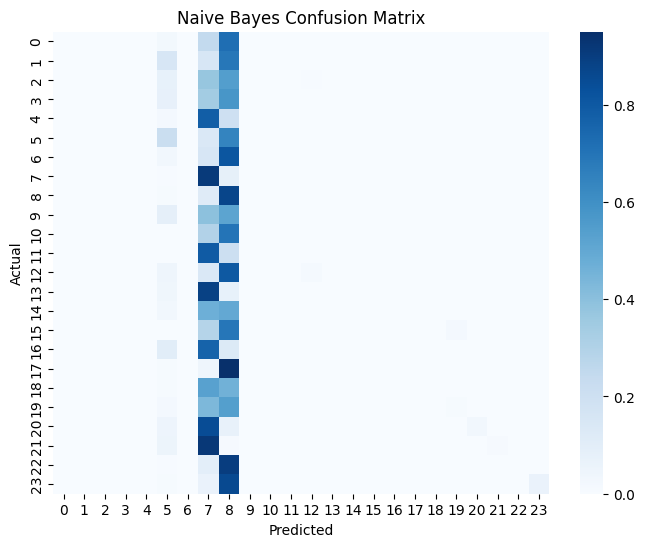

In [ ]:
cm = confusion_matrix(y_val, nb_pred, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
lr_model = LogisticRegression(max_iter=2000,n_jobs=-1)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

In [ ]:
accuracy_score(y_val, lr_pred)

0.5891826475516664

In [ ]:
classification_report(y_val, lr_pred)

C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

'              precision    recall  f1-score   support\n\n      action       0.58      0.22      0.32       296\n       adult       0.83      0.16      0.27       122\n   adventure       0.76      0.19      0.31       145\n   animation       0.33      0.01      0.02        99\n   biography       0.00      0.00      0.00        50\n      comedy       0.53      0.59      0.56      1504\n       crime       0.50      0.01      0.02        90\n documentary       0.66      0.88      0.76      2621\n       drama       0.53      0.81      0.64      2717\n      family       0.50      0.05      0.09       137\n     fantasy       0.00      0.00      0.00        70\n     history       0.00      0.00      0.00        43\n      horror       0.70      0.54      0.61       463\n       music       0.73      0.37      0.49       133\n     musical       0.00      0.00      0.00        62\n     mystery       0.00      0.00      0.00        52\n  reality-tv       0.72      0.10      0.18       178\n     ro

In [ ]:
report = classification_report(y_val, lr_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Priyanka Pal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

,precision,recall,f1-score,support
action,0.575221,0.219595,0.317848,296.000000
adult,0.833333,0.163934,0.273973,122.000000
adventure,0.756757,0.193103,0.307692,145.000000
animation,0.333333,0.010101,0.019608,99.000000
biography,0.000000,0.000000,0.000000,50.000000
comedy,0.531607,0.587101,0.557978,1504.000000
crime,0.500000,0.011111,0.021739,90.000000
documentary,0.664546,0.876765,0.756045,2621.000000
drama,0.533122,0.805668,0.641653,2717.000000
family,0.500000,0.051095,0.092715,137.000000


In [ ]:
report_df.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
action,0.575221,0.219595,0.317848,296.000000
adult,0.833333,0.163934,0.273973,122.000000
adventure,0.756757,0.193103,0.307692,145.000000
animation,0.333333,0.010101,0.019608,99.000000
biography,0.000000,0.000000,0.000000,50.000000
comedy,0.531607,0.587101,0.557978,1504.000000
crime,0.500000,0.011111,0.021739,90.000000
documentary,0.664546,0.876765,0.756045,2621.000000
drama,0.533122,0.805668,0.641653,2717.000000
family,0.500000,0.051095,0.092715,137.000000


In [ ]:
print("\nBest predicted genres:")
print(report_df.sort_values("f1-score", ascending=False).head(10))
print("\nWorst predicted genres:")
print(report_df.sort_values("f1-score").head(10))


Best predicted genres:
              precision    recall  f1-score       support
western        0.928571  0.646766  0.762463    201.000000
documentary    0.664546  0.876765  0.756045   2621.000000
drama          0.533122  0.805668  0.641653   2717.000000
horror         0.703081  0.542117  0.612195    463.000000
accuracy       0.589183  0.589183  0.589183      0.589183
comedy         0.531607  0.587101  0.557978   1504.000000
weighted avg   0.570065  0.589183  0.540384  10742.000000
music          0.731343  0.368421  0.490000    133.000000
short          0.531879  0.306280  0.388719   1035.000000
action         0.575221  0.219595  0.317848    296.000000

Worst predicted genres:
           precision    recall  f1-score  support
mystery     0.000000  0.000000  0.000000     52.0
biography   0.000000  0.000000  0.000000     50.0
musical     0.000000  0.000000  0.000000     62.0
romance     0.000000  0.000000  0.000000    120.0
fantasy     0.000000  0.000000  0.000000     70.0
history     0

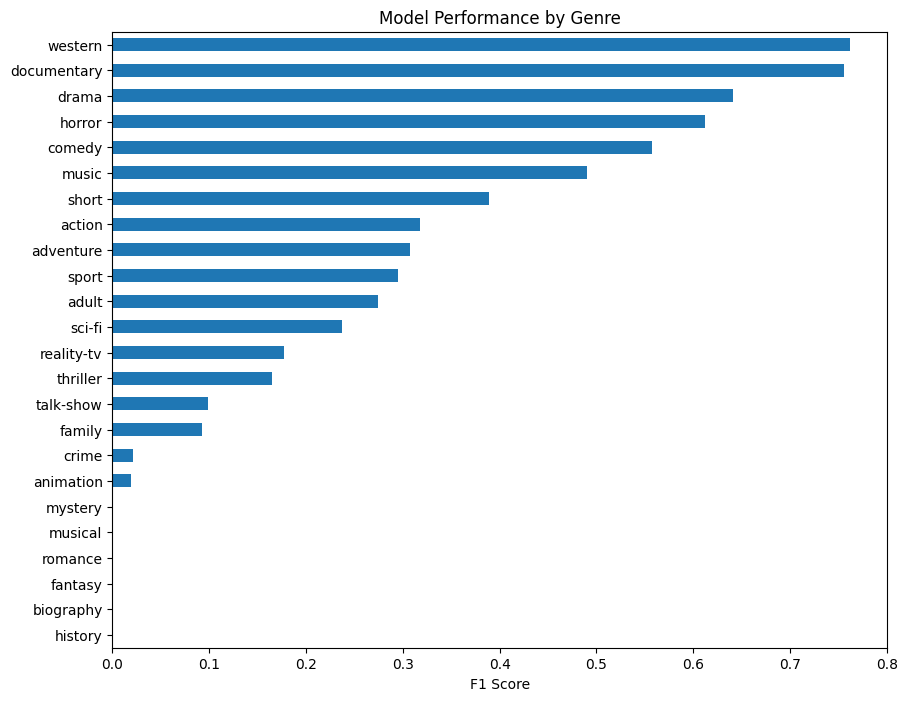

In [ ]:
report_plot = report_df.drop(["accuracy", "macro avg", "weighted avg"])
report_plot["f1-score"].sort_values().plot(kind="barh", figsize=(10,8))
plt.title("Model Performance by Genre")
plt.xlabel("F1 Score")
plt.show()

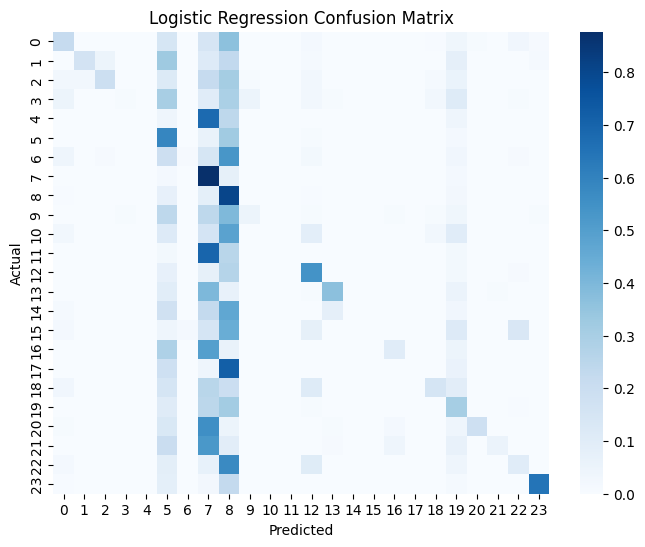

In [ ]:
cm = confusion_matrix(y_val, lr_pred, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:

svm_model = LinearSVC(C=1.5)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)


In [ ]:
accuracy_score(y_val, svm_pred)

0.5792217464159375

In [ ]:
classification_report(y_val, svm_pred)

'              precision    recall  f1-score   support\n\n      action       0.48      0.32      0.39       296\n       adult       0.70      0.44      0.54       122\n   adventure       0.46      0.29      0.36       145\n   animation       0.34      0.19      0.25        99\n   biography       0.00      0.00      0.00        50\n      comedy       0.52      0.57      0.55      1504\n       crime       0.17      0.06      0.08        90\n documentary       0.70      0.81      0.75      2621\n       drama       0.56      0.69      0.62      2717\n      family       0.34      0.18      0.24       137\n     fantasy       0.27      0.06      0.09        70\n     history       0.17      0.02      0.04        43\n      horror       0.65      0.60      0.63       463\n       music       0.55      0.55      0.55       133\n     musical       0.18      0.03      0.05        62\n     mystery       0.36      0.10      0.15        52\n  reality-tv       0.49      0.23      0.31       178\n     ro

In [ ]:
report = classification_report(y_val, svm_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
action,0.477612,0.324324,0.386318,296.000000
adult,0.701299,0.442623,0.542714,122.000000
adventure,0.461538,0.289655,0.355932,145.000000
animation,0.339286,0.191919,0.245161,99.000000
biography,0.000000,0.000000,0.000000,50.000000
comedy,0.522135,0.572473,0.546147,1504.000000
crime,0.166667,0.055556,0.083333,90.000000
documentary,0.699934,0.813430,0.752426,2621.000000
drama,0.556215,0.690099,0.615966,2717.000000
family,0.337838,0.182482,0.236967,137.000000


In [ ]:
report_df.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
action,0.477612,0.324324,0.386318,296.000000
adult,0.701299,0.442623,0.542714,122.000000
adventure,0.461538,0.289655,0.355932,145.000000
animation,0.339286,0.191919,0.245161,99.000000
biography,0.000000,0.000000,0.000000,50.000000
comedy,0.522135,0.572473,0.546147,1504.000000
crime,0.166667,0.055556,0.083333,90.000000
documentary,0.699934,0.813430,0.752426,2621.000000
drama,0.556215,0.690099,0.615966,2717.000000
family,0.337838,0.182482,0.236967,137.000000


In [ ]:
print("\nBest predicted genres:")
print(report_df.sort_values("f1-score", ascending=False).head(10))
print("\nWorst predicted genres:")
print(report_df.sort_values("f1-score").head(10))


Best predicted genres:
              precision    recall  f1-score       support
western        0.834171  0.825871  0.830000    201.000000
documentary    0.699934  0.813430  0.752426   2621.000000
horror         0.654118  0.600432  0.626126    463.000000
drama          0.556215  0.690099  0.615966   2717.000000
accuracy       0.579222  0.579222  0.579222      0.579222
sport          0.725806  0.454545  0.559006     99.000000
weighted avg   0.553878  0.579222  0.557494  10742.000000
music          0.553030  0.548872  0.550943    133.000000
comedy         0.522135  0.572473  0.546147   1504.000000
adult          0.701299  0.442623  0.542714    122.000000

Worst predicted genres:
           precision    recall  f1-score  support
biography   0.000000  0.000000  0.000000     50.0
history     0.166667  0.023256  0.040816     43.0
musical     0.181818  0.032258  0.054795     62.0
romance     0.208333  0.041667  0.069444    120.0
crime       0.166667  0.055556  0.083333     90.0
fantasy     0

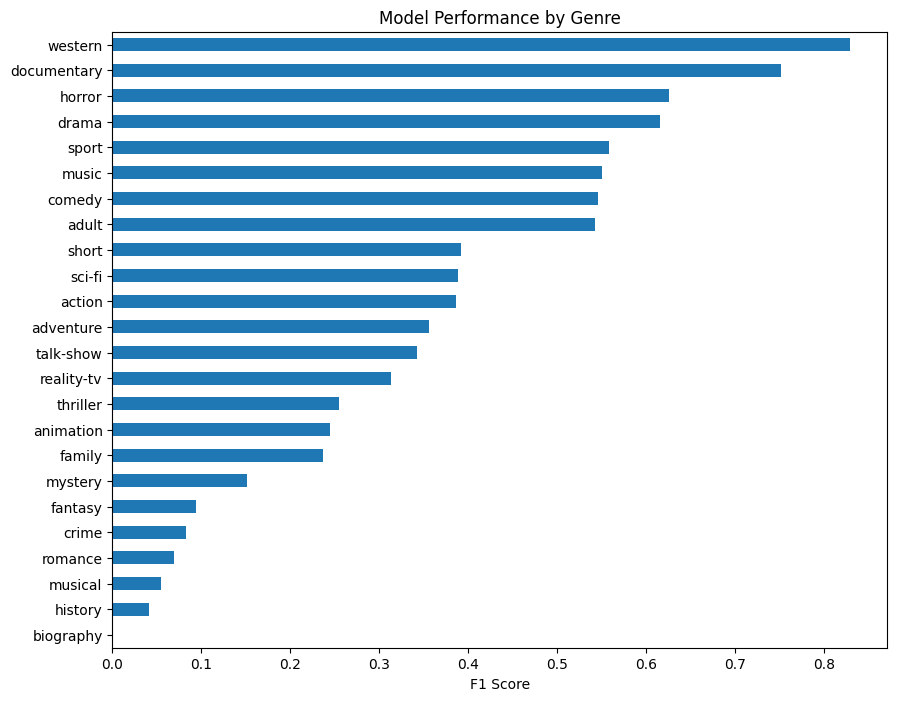

In [ ]:
report_plot = report_df.drop(["accuracy", "macro avg", "weighted avg"])
report_plot["f1-score"].sort_values().plot(kind="barh", figsize=(10,8))
plt.title("Model Performance by Genre")
plt.xlabel("F1 Score")
plt.show()

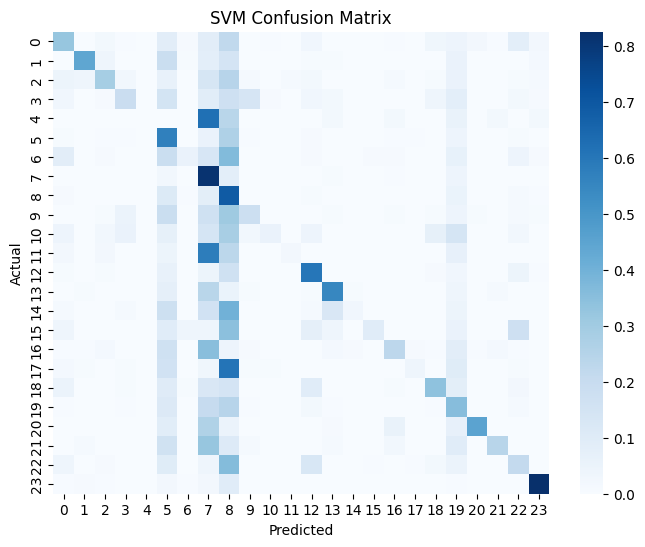

In [ ]:
cm = confusion_matrix(y_val, svm_pred, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def plot_cm(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, cmap="Blues")

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

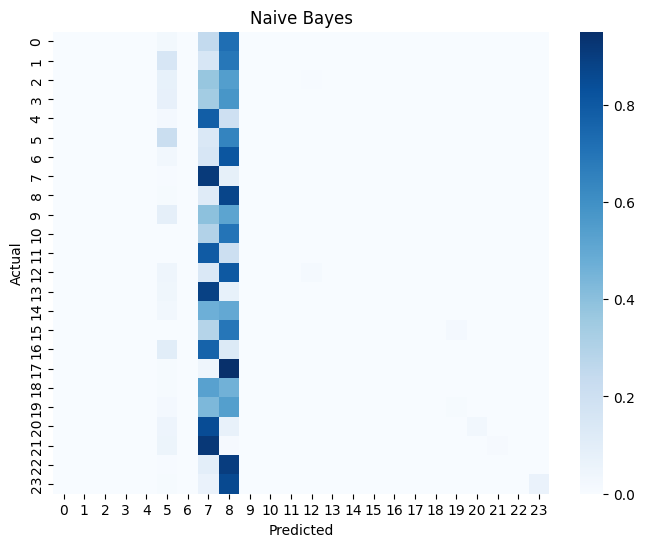

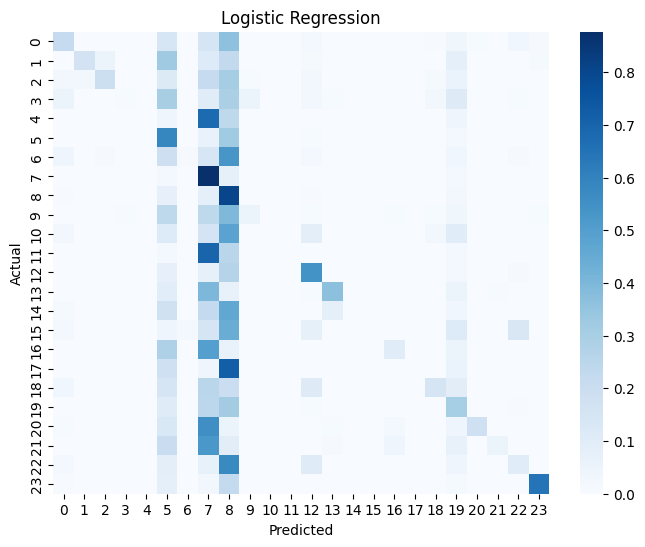

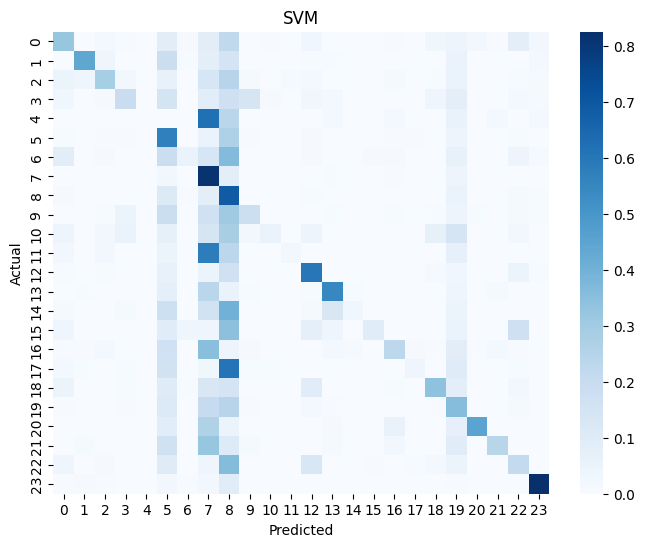

In [ ]:
plot_cm(y_val, nb_pred, "Naive Bayes")
plot_cm(y_val, lr_pred, "Logistic Regression")
plot_cm(y_val, svm_pred, "SVM")

In [ ]:
best_model = lr_model

In [ ]:
X_test = tfidf.transform(test["DESCRIPTION"])

test_predictions = best_model.predict(X_test)

test["PREDICTED_GENRE"] = test_predictions

print(test[["TITLE", "PREDICTED_GENRE"]].head())


                         TITLE PREDICTED_GENRE
0         Edgar's Lunch (1998)           drama
1     La guerra de papá (1977)           drama
2  Off the Beaten Track (2010)           drama
3       Meu Amigo Hindu (2015)           drama
4            Er nu zhai (1955)           drama


In [ ]:
def predict_genre(plot):

    plot = clean_text(plot)

    vector = tfidf.transform([plot])

    prediction = best_model.predict(vector)

    return prediction[0]

In [ ]:
sample_plot = ["A group of astronauts travel through space to save Earth from an alien invasion."]
sample_vec = tfidf.transform(sample_plot)
prediction = best_model.predict(sample_vec)
print("Predicted Genre:", prediction[0])

Predicted Genre: sci-fi


In [ ]:
sample_plot = ["A ghost coming behind me who has already killed my friend "]
sample_vec = tfidf.transform(sample_plot)
prediction = best_model.predict(sample_vec)
print("Predicted Genre:", prediction[0])

Predicted Genre: horror
